In [3]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 93.9 kB/s eta 0:18:03
   ---------------------------------------- 0.0/101.7 MB 145.2 kB/s eta 0:11:40
   ---------------------------------------- 0.0/101.7 MB 145.2 kB/s eta 0:11:40
   ---------------------------------------- 0.0/101.7 MB 131.3 kB/s eta 0:12:55
   ---------------------------------------- 0.1/101.7 MB 182.2 kB/s eta 0:09:18
   ---------------------------------------- 0.1/101.7 MB 313.8 kB/s eta 0:05:24
   ---------------------------------------- 0.2/101.7 MB 497.6 kB/s eta 0:03:24
   ------------

In [4]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Save model
import joblib

In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\keerthana\Downloads\house_prices (1).csv")

df.head()

,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [6]:
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Property_Type  300 non-null    object
 7   Price          300 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 18.9+ KB
None
             Area    Bedrooms   Bathrooms         Age         Price
count   300.00000  300.000000  300.000000  300.000000  3.000000e+02
mean   2759.70000    3.033333    2.026667   25.000000  2.488366e+07
std    1297.68143    1.467219    0.792495   14.332646  1.266525e+07
min     520.00000    1.000000    1.000000    0.000000  3.695000e+06
25%    1675.75000    2.000000    1.000000   12.000000  1.527750e+07
50

In [15]:


# Fill missing values
df = df.ffill()

# Create new feature (example)
if 'area' in df.columns and 'bedrooms' in df.columns:
    df['area_per_room'] = df['area'] / (df['bedrooms'] + 1)

In [19]:
target = 'Price'   # change if needed

X = df.drop(columns=[target])
y = df[target]

# Identify numerical & categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [21]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [27]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42))
])

In [29]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [31]:
models = {
    "Linear Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

    print(f"\n{name}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")


Linear Regression
MAE: 2189373.1208505207
RMSE: 2903982.2723545423
R2: 0.9407861015064383

Random Forest
MAE: 1584147.7083333333
RMSE: 2108213.3603721336
R2: 0.9687920777226098

XGBoost
MAE: 1341553.4833333334
RMSE: 1822027.4138920954
R2: 0.976689824290659


In [33]:
param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1]
}

grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END model__learning_rate=0.01, model__max_depth=4, model__n_estimators=200; total time=   0.1s
[CV] END model__learning_rate=0.01, model__max_depth=4, model__n_estimators=200; total time=   0.1s
[CV] END model__learning_rate=0.01, model__max_depth=4, model__n_estimators=200; total time=   0.0s
[CV] END model__learning_rate=0.01, model__max_depth=4, model__n_estimators=300; total time=   0.1s
[CV] END model__learning_rate=0.01, model__max_depth=4, model__n_estimators=300; total time=   0.1s
[CV] END model__learning_rate=0.01, model__max_depth=4, model__n_estimators=300; total time=   0.2s
[CV] END model__learning_rate=0.01, model__max_depth=6, model__n_estimators=200; total time=   0.1s
[CV] END model__learning_rate=0.01, model__max_depth=6, model__n_estimators=200; total time=   0.1s
[CV] END model__learning_rate=0.01, model__max_depth=6, model__n_estimators=200; total time=   0.1s
[CV] END model__learning_rate=0.01, mod

In [34]:
best_model = grid_search.best_estimator_

preds = best_model.predict(X_test)

print("Final Model Performance:")
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2:", r2_score(y_test, preds))

Final Model Performance:
MAE: 844805.7
RMSE: 1236073.6481652702
R2: 0.9892718600871916


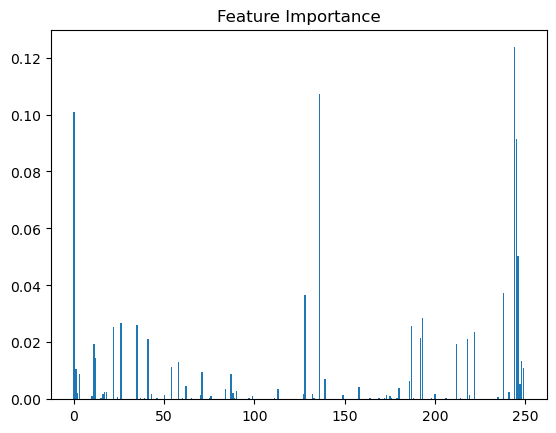

In [37]:
model = best_model.named_steps['model']

importance = model.feature_importances_

plt.figure()
plt.bar(range(len(importance)), importance)
plt.title("Feature Importance")
plt.show()

In [39]:
joblib.dump(best_model, "real_estate_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [41]:
model = joblib.load("real_estate_model.pkl")

sample = X_test.iloc[:1]
prediction = model.predict(sample)

print("Predicted Price:", prediction[0])

Predicted Price: 14127697.0
